<a href="https://colab.research.google.com/github/arthurweslen/PowerQuery_DAX/blob/main/Visuals/Card_Flip_HTML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Card Flip HTML

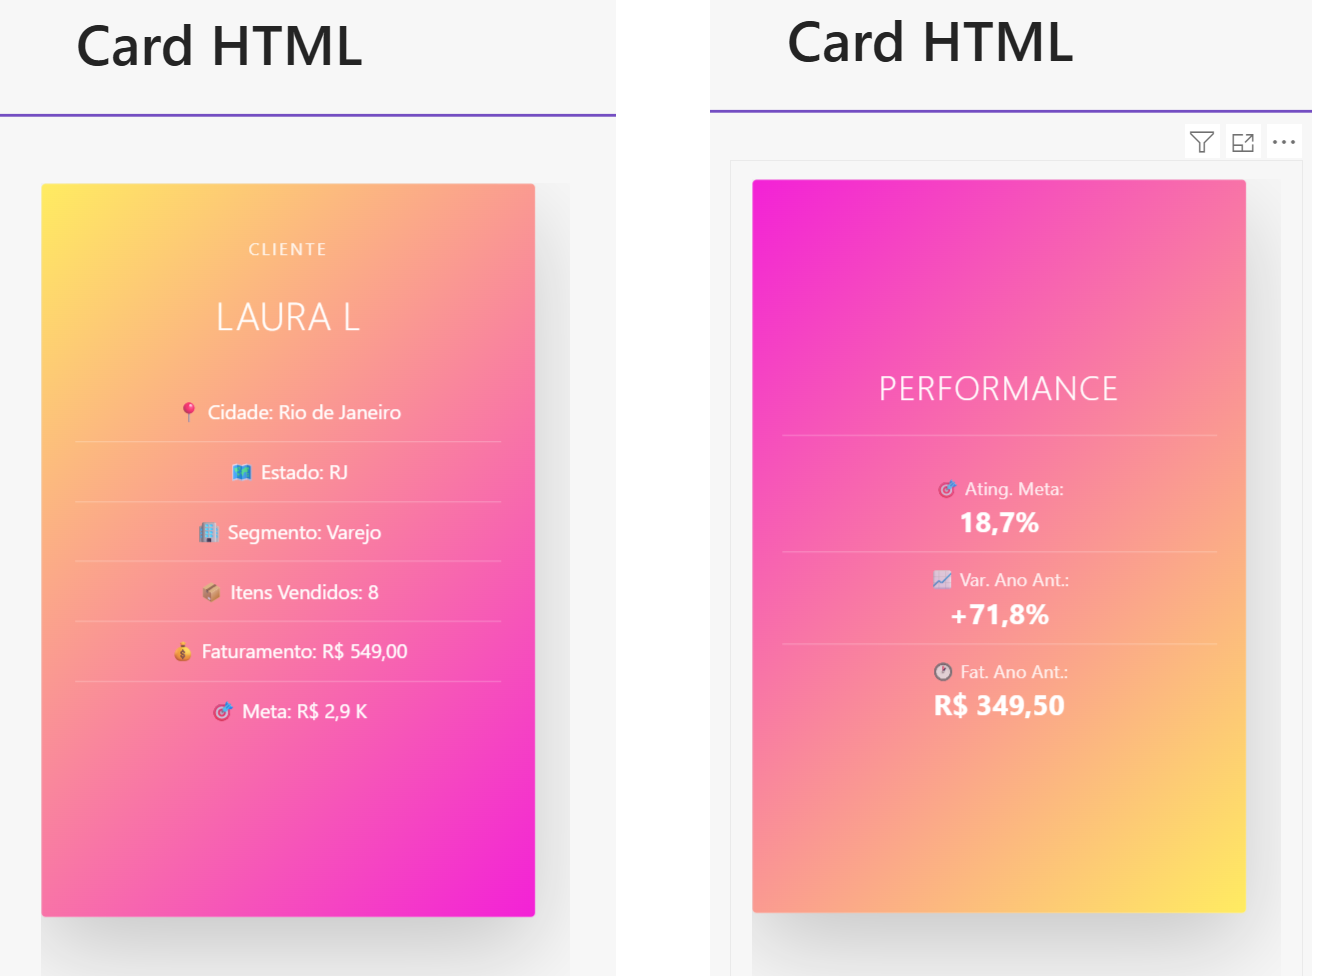

In [ ]:
HTML FlipCard =
//======================================================
//==================== VALORES ========================
VAR varValorTitulo = SELECTEDVALUE(dim_cliente[nome_cliente], "Vários clientes")
VAR varCidade      = SELECTEDVALUE(dim_cliente[cidade],       "Vários")
VAR varEstado      = SELECTEDVALUE(dim_cliente[estado],       "Vários")
VAR varSegmento    = SELECTEDVALUE(dim_cliente[segmento],     "Vários")

VAR FaturamentoAtual = [faturamento_bruto]
VAR FaturamentoMeta  = [faturamento_bruto_meta]
VAR ValorYoY         = [faturamento_bruto YoY %]
VAR AtingimentoMeta  = [%atingimento_meta]
VAR FaturamentoLY    = [ly_faturamento_bruto]
VAR QtdItens         = [quantidade_vendida]

//======================================================

-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                  🎨 PAINEL DE CONTROLE VISUAL                   ║
-- ║   Ajuste tudo aqui sem precisar mexer no HTML lá embaixo        ║
-- ╚══════════════════════════════════════════════════════════════════╝



-- ──────── 🌈 GRADIENTE ────────
-- Altere para 1, 2 ou 3 para escolher o gradiente
-- 1 = Rosa → Azul  |  2 = Rosa → Amarelo  |  3 = Verde → Roxo
VAR GradienteEscolha = 2

VAR FrenteGradiente =
    SWITCH(
        GradienteEscolha,
        1, "linear-gradient(-45deg, #f403d1, #64b5f6)",
        2, "linear-gradient(-45deg, #f321d7, #ffec61)",
        3, "linear-gradient(-45deg, #24ff72, #9a4eff)",
        "linear-gradient(-45deg, #f321d7, #ffec61)"
    )

VAR VersoGradiente =
    SWITCH(
        GradienteEscolha,
        1, "linear-gradient(-45deg, #64b5f6, #f403d1)",
        2, "linear-gradient(-45deg, #ffec61, #f321d7)",
        3, "linear-gradient(-45deg, #9a4eff, #24ff72)",
        "linear-gradient(-45deg, #ffec61, #f321d7)"
    )


-- ──────── 📐 DIMENSÕES DO CARD ────────
VAR LarguraCard  = "350px"
VAR AlturaCard   = "520px"
VAR RaioBordaCard = "3px"
VAR PaddingCard = "32px"


-- ──────── 🔤 FONTE GLOBAL ────────
VAR FonteGlobal = "'Lato', sans-serif"


-- ──────── 🏷️ TEXTOS FIXOS ────────
VAR varTextoTitulo = "Cliente"
VAR varTextoTituloVerso = "Performance"

VAR varTextoAtingimento = "🎯 Ating. Meta:"
VAR varTextoYoY         = "📈 Var. Ano Ant.:"
VAR varTextoFatLY       = "🕐 Fat. Ano Ant.:"

VAR varRotuloCidade      = "📍 Cidade:"
VAR varRotuloEstado      = "🗺️ Estado:"
VAR varRotuloSegmento    = "🏢 Segmento:"
VAR varRotuloItens       = "📦 Itens Vendidos:"
VAR varRotuloFaturamento = "💰 Faturamento:"
VAR varRotuloMeta        = "🎯 Meta:"


-- ──────── 📏 TIPOGRAFIA — FRENTE ────────
VAR TamanhoSubtitulo = "12px"
VAR PesoSubtitulo    = "400"
VAR TamanhoTitulo    = "28px"
VAR PesoTitulo       = "300"
VAR TamanhoLista     = "14px"
VAR PesoLista        = "400"
VAR PaddingItemLista = "9px"


-- ──────── 📏 TIPOGRAFIA — VERSO ────────
VAR TamanhoTituloVerso = "24px"
VAR PesoTituloVerso    = "300"
VAR TamanhoRotuloVerso = "13px"
VAR PesoRotuloVerso    = "400"
VAR TamanhoValorVerso  = "20px"
VAR PesoValorVerso     = "700"
VAR PaddingItemVerso   = "10px"


-- ──────── 🎨 CORES DO TEXTO ────────
VAR CorTexto           = "#FFFFFF"
VAR CorTextoDivider    = "rgba(255, 255, 255, 0.3)"
VAR CorTextoVerso      = "rgba(255, 255, 255, 0.85)"


-- ──────── 🔢 FORMATAÇÃO DOS VALORES ────────
VAR AbreviarFaturamento = TRUE()
VAR CasasDecimais = "2"


-- ──────── 💥 SOMBRA DO CARD ────────
VAR ExibirSombra = TRUE()
VAR SombraCard = IF(ExibirSombra, "0 24px 64px rgba(0, 0, 0, 0.20)", "none")


-- ──────── 🔁 ANIMAÇÃO DO FLIP ────────
VAR DuracaoFlip = "0.8s"
VAR PerspectiveFlip = "2400px"


-- ╔══════════════════════════════════════════════════════════════════╗
-- ║                   ⚙️ LÓGICA DE NEGÓCIO                          ║
-- ║   Normalmente não é necessário mexer abaixo desta linha         ║
-- ╚══════════════════════════════════════════════════════════════════╝

-- ── Formatação do faturamento (frente) ───────────────────────────
VAR FatAbsoluto = ABS(FaturamentoAtual)
VAR FatFormatado =
    IF(
        AbreviarFaturamento,
        SWITCH(
            TRUE(),
            FatAbsoluto >= 1000000000, "R$ " & FORMAT(FaturamentoAtual / 1000000000, "#,##0.0") & " B",
            FatAbsoluto >= 1000000,    "R$ " & FORMAT(FaturamentoAtual / 1000000,    "#,##0.0") & " M",
            FatAbsoluto >= 1000,       "R$ " & FORMAT(FaturamentoAtual / 1000,       "#,##0.0") & " K",
            "R$ " & FORMAT(FaturamentoAtual, "#,##0.00")
        ),
        "R$ " & FORMAT(FaturamentoAtual, "#,##0." & REPT("0", VALUE(CasasDecimais)))
    )

VAR MetaAbsoluto = ABS(FaturamentoMeta)
VAR MetaFormatada =
    IF(
        AbreviarFaturamento,
        SWITCH(
            TRUE(),
            MetaAbsoluto >= 1000000000, "R$ " & FORMAT(FaturamentoMeta / 1000000000, "#,##0.0") & " B",
            MetaAbsoluto >= 1000000,    "R$ " & FORMAT(FaturamentoMeta / 1000000,    "#,##0.0") & " M",
            MetaAbsoluto >= 1000,       "R$ " & FORMAT(FaturamentoMeta / 1000,       "#,##0.0") & " K",
            "R$ " & FORMAT(FaturamentoMeta, "#,##0.00")
        ),
        "R$ " & FORMAT(FaturamentoMeta, "#,##0." & REPT("0", VALUE(CasasDecimais)))
    )

VAR FatLYAbsoluto = ABS(FaturamentoLY)
VAR FatLYFormatado =
    IF(
        AbreviarFaturamento,
        SWITCH(
            TRUE(),
            FatLYAbsoluto >= 1000000000, "R$ " & FORMAT(FaturamentoLY / 1000000000, "#,##0.0") & " B",
            FatLYAbsoluto >= 1000000,    "R$ " & FORMAT(FaturamentoLY / 1000000,    "#,##0.0") & " M",
            FatLYAbsoluto >= 1000,       "R$ " & FORMAT(FaturamentoLY / 1000,       "#,##0.0") & " K",
            "R$ " & FORMAT(FaturamentoLY, "#,##0.00")
        ),
        "R$ " & FORMAT(FaturamentoLY, "#,##0." & REPT("0", VALUE(CasasDecimais)))
    )

-- ── Formatação verso ──────────────────────────────────────────────
VAR AtingFormatado = FORMAT(AtingimentoMeta, "0.0%")
VAR YoYFormatado   = FORMAT(ValorYoY,        "+0.0%;-0.0%;0.0%")
VAR ItensFormatado = FORMAT(QtdItens,        "#,##0")

RETURN
"<!DOCTYPE html>
<html lang='pt-BR'>
<head>
  <meta charset='UTF-8' />
  <meta name='viewport' content='width=device-width, initial-scale=1.0' />
  <link href='https://fonts.googleapis.com/css?family=Lato:100,300,400,700,900' rel='stylesheet'/>
  <style>
    * { margin:0; padding:0; box-sizing:border-box; }

    body {
      font-family: " & FonteGlobal & ";
      font-weight: 400;
      line-height: 1.7;
      color: " & CorTexto & ";
      background: transparent;
      padding: " & PaddingCard & ";
      display: flex;
      justify-content: center;
      align-items: center;
      min-height: 100vh;
    }

    /* ── Card flip ── */
    .flip-card {
      perspective: " & PerspectiveFlip & ";
      position: relative;
      height: " & AlturaCard & ";
      width: " & LarguraCard & ";
    }

    .flip-side {
      height: " & AlturaCard & ";
      width: 100%;
      position: absolute;
      top: 0; left: 0;
      backface-visibility: hidden;
      border-radius: " & RaioBordaCard & ";
      overflow: hidden;
      transition: transform " & DuracaoFlip & " ease;
      box-shadow: " & SombraCard & ";
      color: " & CorTexto & ";
    }

    .flip-front { background: " & FrenteGradiente & "; }
    .flip-back  {
      background: " & VersoGradiente & ";
      transform: rotateY(180deg);
    }
    .flip-card:hover .flip-front { transform: rotateY(-180deg); }
    .flip-card:hover .flip-back  { transform: rotateY(0deg); }

    /* ── Frente ── */
    .flip-header {
      padding: 36px 20px 16px;
      display: flex;
      flex-direction: column;
      justify-content: center;
      align-items: center;
      text-align: center;
    }

    .flip-subtitle {
      font-size: " & TamanhoSubtitulo & ";
      font-weight: " & PesoSubtitulo & ";
      text-transform: uppercase;
      letter-spacing: 1.8px;
      margin-bottom: 8px;
      opacity: 0.85;
    }

    .flip-title {
      font-size: " & TamanhoTitulo & ";
      font-weight: " & PesoTitulo & ";
      text-transform: uppercase;
      width: 85%;
      word-break: break-word;
      line-height: 1.3;
    }

    .flip-details { padding: 4px 24px 20px; }

    .flip-details ul { list-style: none; width: 100%; margin: 0 auto; }

    .flip-details ul li {
      text-align: center;
      font-size: " & TamanhoLista & ";
      font-weight: " & PesoLista & ";
      padding: " & PaddingItemLista & " 0;
      border-bottom: 1px solid " & CorTextoDivider & ";
    }
    .flip-details ul li:last-child { border-bottom: none; }

    /* ── Verso ── */
    .flip-back-content {
      position: absolute;
      top: 50%;
      left: 50%;
      transform: translate(-50%, -50%);
      width: 88%;
      text-align: center;
    }

    .flip-back-title {
      font-size: " & TamanhoTituloVerso & ";
      font-weight: " & PesoTituloVerso & ";
      text-transform: uppercase;
      letter-spacing: 1px;
      margin-bottom: 18px;
      padding-bottom: 14px;
      border-bottom: 1px solid " & CorTextoDivider & ";
    }

    .flip-back-item {
      padding: " & PaddingItemVerso & " 0;
      border-bottom: 1px solid " & CorTextoDivider & ";
    }
    .flip-back-item:last-child { border-bottom: none; }

    .flip-back-label {
      font-size: " & TamanhoRotuloVerso & ";
      font-weight: " & PesoRotuloVerso & ";
      color: " & CorTextoVerso & ";
      line-height: 1.4;
    }

    .flip-back-value {
      font-size: " & TamanhoValorVerso & ";
      font-weight: " & PesoValorVerso & ";
      margin-top: 2px;
      line-height: 1.2;
    }
  </style>
</head>
<body>
  <div class='flip-card'>

    <!-- ═══ FRENTE ═══ -->
    <div class='flip-side flip-front'>
      <div class='flip-header'>
        <span class='flip-subtitle'>" & varTextoTitulo & "</span>
        <h4 class='flip-title'>" & varValorTitulo & "</h4>
      </div>
      <div class='flip-details'>
        <ul>
          <li>" & varRotuloCidade      & " " & varCidade      & "</li>
          <li>" & varRotuloEstado      & " " & varEstado      & "</li>
          <li>" & varRotuloSegmento    & " " & varSegmento    & "</li>
          <li>" & varRotuloItens       & " " & ItensFormatado & "</li>
          <li>" & varRotuloFaturamento & " " & FatFormatado   & "</li>
          <li>" & varRotuloMeta        & " " & MetaFormatada  & "</li>
        </ul>
      </div>
    </div>

    <!-- ═══ VERSO ═══ -->
    <div class='flip-side flip-back'>
      <div class='flip-back-content'>
        <div class='flip-back-title'>" & varTextoTituloVerso & "</div>

        <div class='flip-back-item'>
          <div class='flip-back-label'>" & varTextoAtingimento & "</div>
          <div class='flip-back-value'>" & AtingFormatado & "</div>
        </div>

        <div class='flip-back-item'>
          <div class='flip-back-label'>" & varTextoYoY & "</div>
          <div class='flip-back-value'>" & YoYFormatado & "</div>
        </div>

        <div class='flip-back-item'>
          <div class='flip-back-label'>" & varTextoFatLY & "</div>
          <div class='flip-back-value'>" & FatLYFormatado & "</div>
        </div>
      </div>
    </div>

  </div>
</body>
</html>"